<a href="https://colab.research.google.com/github/louannmichelpro-arch/portfolio-risk-analysis/blob/main/risque_portefeuilles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install yfinance pandas numpy matplotlib

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["URTH", "EZU", "AGG", "GLD"]
prix = yf.download(tickers, start="2016-01-01", auto_adjust=True)["Close"]

print(prix.head())
print(prix.isna().sum())

[*********************100%***********************]  4 of 4 completed

Ticker            AGG        EZU         GLD       URTH
Date                                                   
2016-01-04  79.940132  25.856529  102.889999  56.760036
2016-01-05  79.977196  25.631496  103.180000  56.362892
2016-01-06  80.280754  25.211437  104.669998  55.709244
2016-01-07  80.273315  24.858879  106.150002  53.905502
2016-01-08  80.451042  24.633844  105.680000  53.624176
Ticker
AGG     0
EZU     0
GLD     0
URTH    0
dtype: int64


In [6]:
rendements = prix.pct_change().dropna()
print(rendements.describe())

Ticker          AGG          EZU          GLD         URTH
count   2700.000000  2700.000000  2700.000000  2700.000000
mean       0.000067     0.000438     0.000539     0.000538
std        0.003339     0.012847     0.010366     0.010811
min       -0.040010    -0.126795    -0.102742    -0.113776
25%       -0.001509    -0.005677    -0.004677    -0.003795
50%        0.000178     0.000980     0.000706     0.000866
75%        0.001707     0.006895     0.005679     0.005703
max        0.023721     0.088810     0.063587     0.090963


In [7]:
prix.isna().sum()

,0
Ticker,
AGG,0
EZU,0
GLD,0
URTH,0


In [9]:
rendements.std() * np.sqrt(252)

,0
Ticker,
AGG,0.053002
EZU,0.203942
GLD,0.164555
URTH,0.171614


In [10]:
correlation = rendements.corr()
print(correlation)

Ticker       AGG       EZU       GLD      URTH
Ticker                                        
AGG     1.000000  0.172391  0.324129  0.156409
EZU     0.172391  1.000000  0.156482  0.874439
GLD     0.324129  0.156482  1.000000  0.122706
URTH    0.156409  0.874439  0.122706  1.000000


In [11]:
poids = {
    "Prudent": np.array([0.70, 0.05, 0.10, 0.15]),
    "Équilibré": np.array([0.40, 0.15, 0.10, 0.35]),
    "Dynamique": np.array([0.10, 0.25, 0.10, 0.55])
  }

portefeuilles=pd.DataFrame()

for nom, w in poids.items():
  portefeuilles[nom]=(rendements * w).sum(axis=1)

vol_portefeuilles = portefeuilles.std() * np.sqrt(252)
print("---Volatilité annualisée des portefeuilles---")
print(vol_portefeuilles)

---Volatilité annualisée des portefeuilles---
Prudent      0.062084
Équilibré    0.098618
Dynamique    0.145512
dtype: float64


In [12]:
import scipy.stats as stats

# VaR 95% Historique quotidienne
var_hist_95 = -portefeuilles.quantile(0.05)

# VaR 95% Paramétrique quotidienne
moyennes = portefeuilles.mean()
ecart_types = portefeuilles.std()
var_param_95 = -(moyennes - 1.645 * ecart_types)

# Tableau comparatif
var_df = pd.DataFrame({
    'VaR Hist 95% (1j)': var_hist_95,
    'VaR Param 95% (1j)': var_param_95
})

print("--- Value-at-Risk (VaR) Quotidienne à 95% ---")
print(var_df * 100) # exprimé en %

--- Value-at-Risk (VaR) Quotidienne à 95% ---
           VaR Hist 95% (1j)  VaR Param 95% (1j)
Prudent             0.579809            0.622984
Équilibré           0.870832            0.988454
Dynamique           1.320165            1.461272


In [13]:
valeur_cumulee = (1 + portefeuilles).cumprod()

peaks = valeur_cumulee.cummax()

drawdowns = (valeur_cumulee - peaks) / peaks

max_drawdown = drawdowns.min()

print("--- Maximum Drawdown (Perte Max Historique) ---")
print(max_drawdown * 100)

--- Maximum Drawdown (Perte Max Historique) ---
Prudent     -18.179764
Équilibré   -21.433653
Dynamique   -28.847495
dtype: float64


In [14]:
covid_2020 = (1 + portefeuilles.loc['2020-02-19':'2020-03-23']).prod() - 1

annee_2022 = (1 + portefeuilles.loc['2022-01-01':'2022-12-31']).prod() - 1

crises_df = pd.DataFrame({
    'Crash Covid (Fev-Mar 2020)': covid_2020 * 100,
    'Année 2022 (Inflation)': annee_2022 * 100
})

print("--- Performance pendant les crises (en %) ---")
print(crises_df)

--- Performance pendant les crises (en %) ---
           Crash Covid (Fev-Mar 2020)  Année 2022 (Inflation)
Prudent                     -8.734470              -12.398249
Équilibré                  -19.026305              -13.590116
Dynamique                  -28.534544              -15.171850


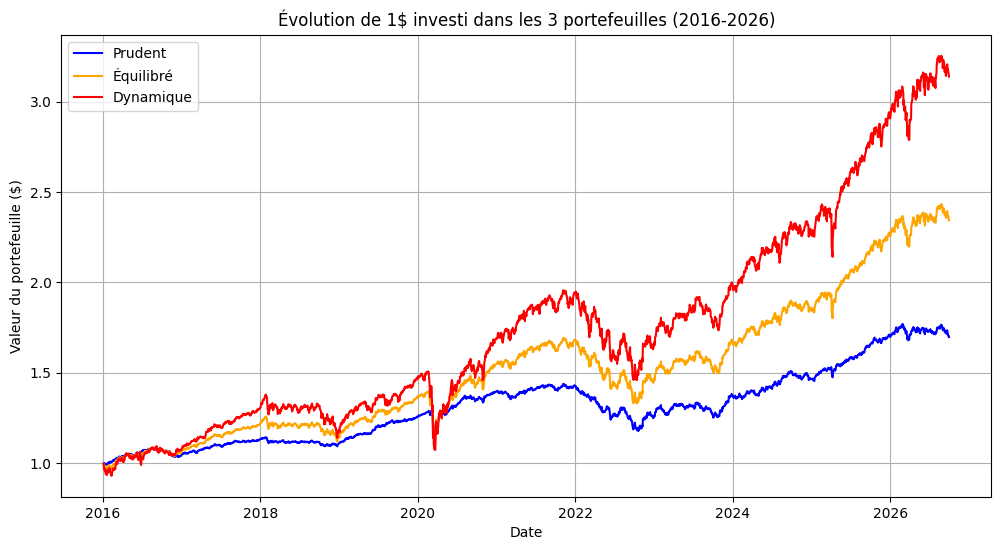

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(valeur_cumulee['Prudent'], label='Prudent', color='blue')
plt.plot(valeur_cumulee['Équilibré'], label='Équilibré', color='orange')
plt.plot(valeur_cumulee['Dynamique'], label='Dynamique', color='red')

plt.title('Évolution de 1$ investi dans les 3 portefeuilles (2016-2026https://github.com/louannmichelpro-arch/portfolio-risk-analysis/tree/main$0)')
plt.xlabel('Date')
plt.ylabel('Valeur du portefeuille ($)')
plt.legend()
plt.grid(True)
plt.show()